# Phase 3 — Backtesting

**Objectif du notebook :**
Transformer la stratégie de cointégration en une stratégie testée honnêtement.
À la fin, on doit pouvoir répondre à :
1. La stratégie est-elle profitable après frais de transaction ?
2. Les paramètres (seuils z-score, fenêtres) sont-ils robustes out-of-sample ?
3. Quels sont les risques réels (drawdown, durée des pertes, fréquence des signaux) ?
4. La performance est-elle due à la stratégie ou à de la chance sur les données ?

---

In [76]:
# imports
import sys
sys.path.append('..')  # Pour importer depuis src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.research.cointegration import adf_test
from pathlib import Path # pour gérer les chemins de fichiers de manière plus robuste

from src.processing.cleaning import load_ohlcv, align_pairs, detect_gaps
from src.features.features import log_returns, rolling_zscore, rolling_correlation
from src.utils.plotting import plot_prices, plot_log_returns, plot_rolling_correlation, plot_spread, plot_zscore
from src.research.cointegration import compute_beta, compute_rolling_spread, johansen_test, rolling_johansen, compute_halflife, compute_empirical_halflife
from src.research.backtesting import generate_signals, simulate_pnl_real, compute_metrics_clean, walk_forward, plot_pnl, plot_walk_forward

plt.style.use('seaborn-v0_8-whitegrid')

# chaque modification dans src/ est automatiquement rechargée sans avoir à faire importlib.reload à la main.
%load_ext autoreload
%autoreload 2

print('Imports OK')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK


In [77]:
PROCESSED_DIR = Path('..') / 'data' / 'processed'

df_btc = pd.read_parquet(PROCESSED_DIR / 'BTCUSDT_15m_clean.parquet')
df_eth = pd.read_parquet(PROCESSED_DIR / 'ETHUSDT_15m_clean.parquet')

log_btc = np.log(df_btc['Close'])
log_eth = np.log(df_eth['Close'])

In [78]:
# ── Paramètres ────────────────────────────────────────────────────────────────
window_beta   = 2 * 24 * 4    # 2 jours pour le β
window_zscore = 5 * 24 * 4    # 5 jours pour le z-score
CAPITAL       = 10_000

In [79]:
# ── Pipeline ──────────────────────────────────────────────────────────────────
spread_full = compute_rolling_spread(log_btc, log_eth, window_beta)
zscore_full = rolling_zscore(spread_full, window=window_zscore)
signal_full = generate_signals(zscore_full)

In [81]:
# ── β pour le hedge ───────────────────────────────────────────────────────────
log_btc = log_btc.dropna()
log_eth = log_eth.dropna()
beta = compute_beta(log_btc.values[-window_beta:], log_eth.values[-window_beta:])
print(f"β : {beta:.4f}")

β : 0.7964


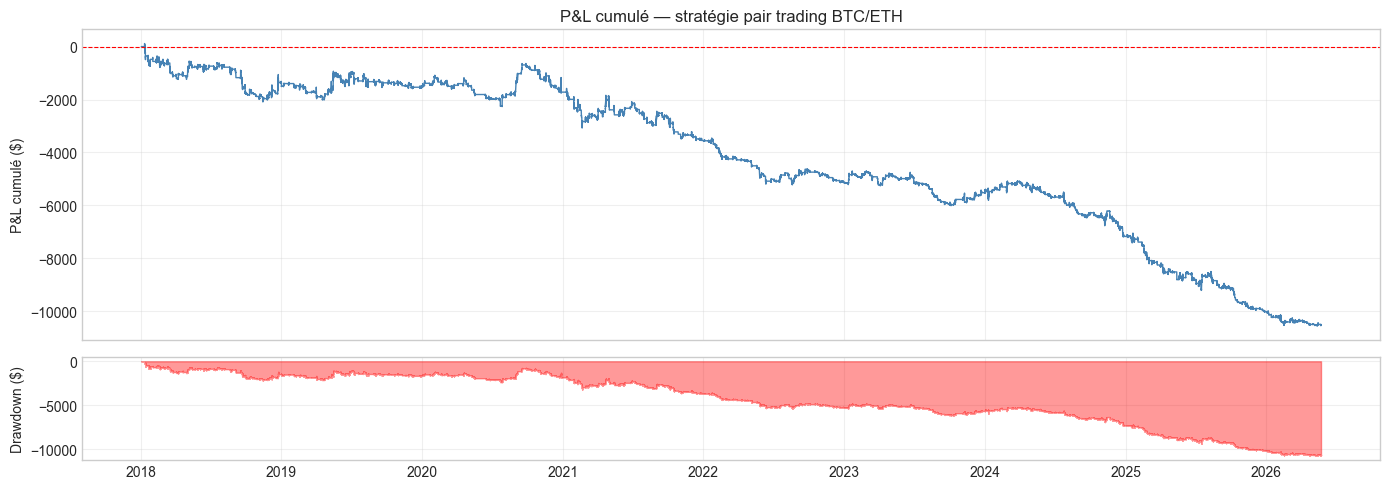

In [82]:
# ── P&L ───────────────────────────────────────────────────────────────────────
pnl_full = simulate_pnl_real(df_btc, df_eth, signal_full, beta, capital=CAPITAL)
plot_pnl(pnl_full, title='P&L cumulé — stratégie pair trading BTC/ETH')

In [83]:
# ── Métriques ─────────────────────────────────────────────────────────────────
metrics = compute_metrics_clean(pnl_full, signal_full, capital=CAPITAL)

Sharpe ratio      : -1.232
Return total      : -10500.0$
Max drawdown      : -10674.0$
Win rate          : 13.6%
Nombre de trades  : 1217


Sharpe positif : 28% des fenêtres
Sharpe moyen   : -1.319
Sharpe min     : -4.141
Sharpe max     : 1.782


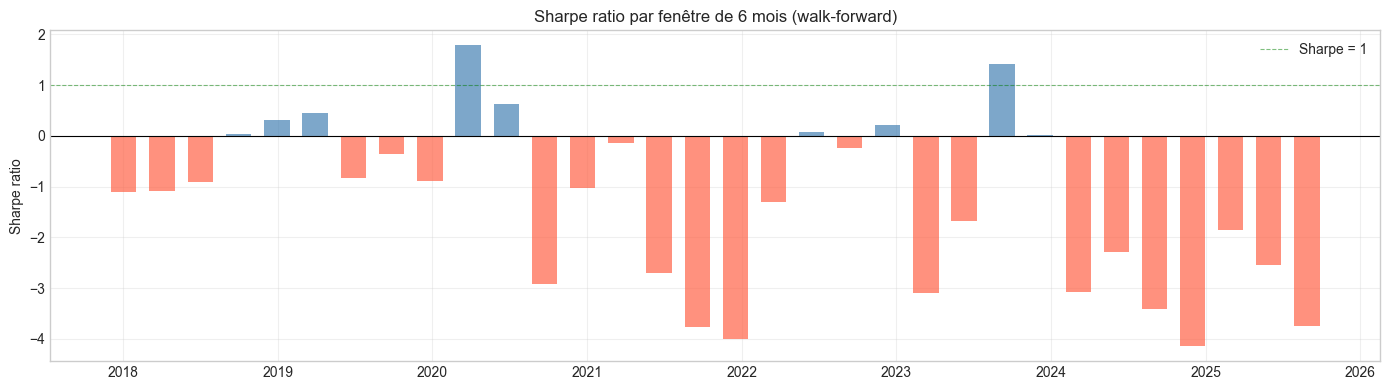

In [84]:
# ── Walk-forward ──────────────────────────────────────────────────────────────
df_wf = walk_forward(pnl_full, signal_full, window_days=180, step_days=90, capital=CAPITAL)
plot_walk_forward(df_wf)